In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("imtkaggleteam/international-airlines-traffic-by-city-pairs")

if os.path.isdir(path):
    print(f"Dl to directory: {path}")
    files = os.listdir(path)
    print(f"Files in directory: {files}")

    csv_files = [f for f in files if f.endswith('.csv')]
    if csv_files:
        csv_path = os.path.join(path, csv_files[0])
        print(f"Reading CSV file: {csv_path}")
        df = pd.read_csv(csv_path)
    else:
        print("No CSV files found in the directory")
        df = None
print("Path to dataset files:", path)

df.head()

Dl to directory: C:\Users\ASUS\.cache\kagglehub\datasets\imtkaggleteam\international-airlines-traffic-by-city-pairs\versions\1
Files in directory: ['city_pairs.csv']
Reading CSV file: C:\Users\ASUS\.cache\kagglehub\datasets\imtkaggleteam\international-airlines-traffic-by-city-pairs\versions\1\city_pairs.csv
Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\imtkaggleteam\international-airlines-traffic-by-city-pairs\versions\1


,Month,AustralianPort,ForeignPort,Country,Passengers_In,Freight_In_(tonnes),Mail_In_(tonnes),Passengers_Out,Freight_Out_(tonnes),Mail_Out_(tonnes),Passengers_Total,Freight_Total_(tonnes),Mail_Total_(tonnes),Year,Month_num
0,Jan-85,Adelaide,Auckland,New Zealand,1513,42.167,0.311,985,18.704,0.924,2498,60.871,1.235,1985,1
1,Jan-85,Adelaide,Bahrain,Bahrain,12,0.000,0.000,5,0.033,0.000,17,0.033,0.000,1985,1
2,Jan-85,Adelaide,Bombay,India,7,0.000,0.000,5,0.000,0.000,12,0.000,0.000,1985,1
3,Jan-85,Adelaide,Frankfurt,Germany,115,0.009,0.000,171,0.000,0.248,286,0.009,0.248,1985,1
4,Jan-85,Adelaide,London,UK,1567,2.800,0.000,1472,10.618,2.487,3039,13.418,2.487,1985,1


In [3]:
df.describe()

,Passengers_In,Freight_In_(tonnes),Mail_In_(tonnes),Passengers_Out,Freight_Out_(tonnes),Mail_Out_(tonnes),Passengers_Total,Freight_Total_(tonnes),Mail_Total_(tonnes),Year,Month_num
count,89320.000000,89320.000000,89320.000000,89320.000000,89320.000000,89320.000000,89320.000000,89320.000000,89320.000000,89320.000000,89320.000000
mean,4561.972380,167.342670,7.442728,4491.480743,148.406850,4.628451,9053.453124,315.749520,12.071179,2003.077541,6.498959
std,8564.725065,407.415238,23.809746,8416.198365,363.853783,14.769693,16905.519449,728.108373,34.345207,11.222014,3.472430
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1985.000000,1.000000
25%,128.000000,0.002000,0.000000,133.000000,0.011750,0.000000,284.000000,0.781000,0.000000,1994.000000,3.000000
50%,1290.000000,14.962000,0.000000,1265.000000,14.072000,0.000000,2573.000000,43.536000,0.105000,2001.000000,7.000000
75%,4831.000000,136.583750,1.703000,4698.250000,118.125500,1.551250,9614.000000,275.003250,4.932000,2013.000000,10.000000
max,90926.000000,6764.923000,393.705000,91078.000000,4996.582000,382.229000,170469.000000,9889.553000,566.993000,2025.000000,12.000000


In [4]:
# Basic information
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (89320, 15)

Columns: ['Month', 'AustralianPort', 'ForeignPort', 'Country', 'Passengers_In', 'Freight_In_(tonnes)', 'Mail_In_(tonnes)', 'Passengers_Out', 'Freight_Out_(tonnes)', 'Mail_Out_(tonnes)', 'Passengers_Total', 'Freight_Total_(tonnes)', 'Mail_Total_(tonnes)', 'Year', 'Month_num']

Data Types:
Month                      object
AustralianPort             object
ForeignPort                object
Country                    object
Passengers_In               int64
Freight_In_(tonnes)       float64
Mail_In_(tonnes)          float64
Passengers_Out              int64
Freight_Out_(tonnes)      float64
Mail_Out_(tonnes)         float64
Passengers_Total            int64
Freight_Total_(tonnes)    float64
Mail_Total_(tonnes)       float64
Year                        int64
Month_num                   int64
dtype: object

Missing Values:
Month                     0
AustralianPort            0
ForeignPort               0
Country                   0
Passengers_In             0
Fr

In [5]:
print("Top 10 Australian Ports by Total Passengers:")
print(df.groupby("AustralianPort")['Passengers_Total'].sum().sort_values(ascending=False).head(10))
print("------------------------------------------")
print("Top 10 Destination by Total Passengers")
print(df.groupby(['ForeignPort', "Country"])['Passengers_Total'].sum().sort_values(ascending=False).head(10))
print("------------------------------------------")
print("Top 10 Countries by Total Passengers")
print(df.groupby("Country")['Passengers_Total'].sum().sort_values(ascending=False).head(10))

Top 10 Australian Ports by Total Passengers:
AustralianPort
Sydney                    353767119
Melbourne                 185703821
Brisbane                  122398330
Perth                      87102085
Cairns                     20778500
Adelaide                   17331237
Gold Coast                 12156505
Darwin                      6407916
Gold Coast/Coolangatta      1255075
Norfolk Island               526133
Name: Passengers_Total, dtype: int64
------------------------------------------
Top 10 Destination by Total Passengers
ForeignPort   Country             
Singapore     Singapore               122491551
Auckland      New Zealand             100390553
Denpasar      Indonesia                45485465
Kuala Lumpur  Malaysia                 44930832
Los Angeles   USA                      41185215
Dubai         United Arab Emirates     35343211
Tokyo         Japan                    33725907
Hong Kong     Hong Kong (SAR)          32275109
Christchurch  New Zealand              313

In [6]:
print("Top 10 Australian Ports by Total Passengers:")
print(df.groupby("AustralianPort")['Passengers_Total'].sum().sort_values(ascending=False).head(10))
print("------------------------------------------")
print("Top 10 Destination by Total Passengers")
print(df.groupby(['ForeignPort', "Country"])['Passengers_Total'].sum().sort_values(ascending=False).head(10))
print("------------------------------------------")
print("Top 10 Countries by Total Passengers")
print(df.groupby("Country")['Passengers_Total'].sum().sort_values(ascending=False).head(10))

Top 10 Australian Ports by Total Passengers:
AustralianPort
Sydney                    353767119
Melbourne                 185703821
Brisbane                  122398330
Perth                      87102085
Cairns                     20778500
Adelaide                   17331237
Gold Coast                 12156505
Darwin                      6407916
Gold Coast/Coolangatta      1255075
Norfolk Island               526133
Name: Passengers_Total, dtype: int64
------------------------------------------
Top 10 Destination by Total Passengers
ForeignPort   Country             
Singapore     Singapore               122491551
Auckland      New Zealand             100390553
Denpasar      Indonesia                45485465
Kuala Lumpur  Malaysia                 44930832
Los Angeles   USA                      41185215
Dubai         United Arab Emirates     35343211
Tokyo         Japan                    33725907
Hong Kong     Hong Kong (SAR)          32275109
Christchurch  New Zealand              313

In [12]:
print(df.groupby("AustralianPort")["Freight_In_(tonnes)"].sum().sort_values(ascending=False).head(10))
print("\n"+"---------------------------------"+"\n")
print(df.groupby("AustralianPort")["Freight_Out_(tonnes)"].sum().sort_values(ascending=False).head(10))
print("\n"+"---------------------------------"+"\n")
print(df.groupby("AustralianPort")["Mail_In_(tonnes)"].sum().sort_values(ascending=False).head(10))
print("\n"+"---------------------------------"+"\n")
print(df.groupby("AustralianPort")["Mail_Out_(tonnes)"].sum().sort_values(ascending=False).head(10))
print("\n"+"---------------------------------"+"\n")


AustralianPort
Sydney                8415146.015
Melbourne             3815018.620
Brisbane              1348150.518
Perth                  986774.590
Adelaide               246389.230
Cairns                  65814.178
Gold Coast              46101.170
Darwin                  12644.899
Norfolk Island           3808.875
Toowoomba Wellcamp       1756.633
Name: Freight_In_(tonnes), dtype: float64

---------------------------------

AustralianPort
Sydney                5775542.611
Melbourne             3874943.554
Brisbane              1683570.782
Perth                 1349916.535
Adelaide               337273.194
Cairns                 181249.898
Darwin                  20405.353
Gold Coast              16687.739
Toowoomba Wellcamp      11418.691
Townsville               2639.504
Name: Freight_Out_(tonnes), dtype: float64

---------------------------------

AustralianPort
Sydney              417989.004
Melbourne           164939.072
Brisbane             50105.225
Perth                2564

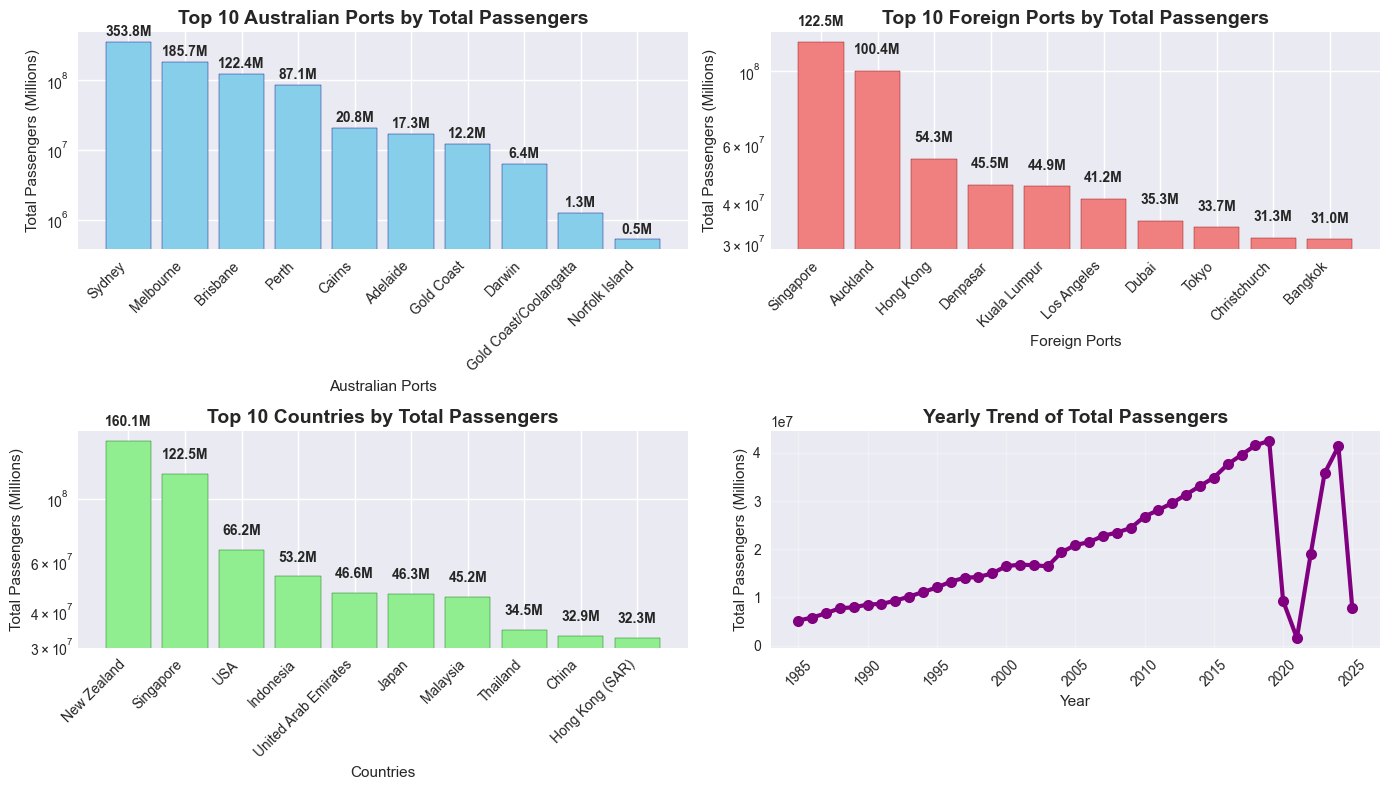

=== SUMMARY STATISTICS ===
Total Records: 89,320
Time Period: 1985 - 2025
Total Passengers: 808,654,433
Total Freight: 28,202,747 tonnes
Total Mail: 1,078,198 tonnes
Unique Australian Ports: 19
Unique Foreign Ports: 200
Unique Countries: 78


In [ ]:
# Set up the plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. TOP AUSTRALIAN PORTS BY TOTAL PASSENGERS
plt.figure(figsize=(14, 8))
top_ports = df.groupby("AustralianPort")['Passengers_Total'].sum().sort_values(ascending=False).head(10)
plt.subplot(2, 2, 1)
bars = plt.bar(range(len(top_ports)), top_ports.values, color='skyblue', edgecolor='navy')
plt.title('Top 10 Australian Ports by Total Passengers', fontsize=14, fontweight='bold')
plt.xlabel('Australian Ports')
plt.ylabel('Total Passengers (Millions)')
plt.xticks(range(len(top_ports)), top_ports.index, rotation=45, ha='right')
plt.yscale('log')  # Log scale for better visualization
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, 
             f'{top_ports.values[i]/1e6:.1f}M', ha='center', va='bottom', fontweight='bold')

# 2. TOP FOREIGN PORTS BY TOTAL PASSENGERS
top_foreign = df.groupby('ForeignPort')['Passengers_Total'].sum().sort_values(ascending=False).head(10)
plt.subplot(2, 2, 2)
bars = plt.bar(range(len(top_foreign)), top_foreign.values, color='lightcoral', edgecolor='darkred')
plt.title('Top 10 Foreign Ports by Total Passengers', fontsize=14, fontweight='bold')
plt.xlabel('Foreign Ports')
plt.ylabel('Total Passengers (Millions)')
plt.xticks(range(len(top_foreign)), top_foreign.index, rotation=45, ha='right')
plt.yscale('log')
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, 
             f'{top_foreign.values[i]/1e6:.1f}M', ha='center', va='bottom', fontweight='bold')

# 3. TOP COUNTRIES BY TOTAL PASSENGERS
top_countries = df.groupby('Country')['Passengers_Total'].sum().sort_values(ascending=False).head(10)
plt.subplot(2, 2, 3)
bars = plt.bar(range(len(top_countries)), top_countries.values, color='lightgreen', edgecolor='darkgreen')
plt.title('Top 10 Countries by Total Passengers', fontsize=14, fontweight='bold')
plt.xlabel('Countries')
plt.ylabel('Total Passengers (Millions)')
plt.xticks(range(len(top_countries)), top_countries.index, rotation=45, ha='right')
plt.yscale('log')
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1, 
             f'{top_countries.values[i]/1e6:.1f}M', ha='center', va='bottom', fontweight='bold')

# 4. YEARLY TREND OF TOTAL PASSENGERS
yearly_trend = df.groupby('Year')['Passengers_Total'].sum()
plt.subplot(2, 2, 4)
plt.plot(yearly_trend.index, yearly_trend.values, marker='o', linewidth=3, markersize=8, color='purple')
plt.title('Yearly Trend of Total Passengers', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Passengers (Millions)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("=== SUMMARY STATISTICS ===")
print(f"Total Records: {len(df):,}")
print(f"Time Period: {df['Year'].min()} - {df['Year'].max()}")
print(f"Total Passengers: {df['Passengers_Total'].sum():,.0f}")
print(f"Total Freight: {df['Freight_Total_(tonnes)'].sum():,.0f} tonnes")
print(f"Total Mail: {df['Mail_Total_(tonnes)'].sum():,.0f} tonnes")
print(f"Unique Australian Ports: {df['AustralianPort'].nunique()}")
print(f"Unique Foreign Ports: {df['ForeignPort'].nunique()}")
print(f"Unique Countries: {df['Country'].nunique()}")

In [37]:
# Seasonal patterns
monthly_traffic = df.groupby(['Year', 'Month_num'])['Passengers_Total'].sum().reset_index()
monthly_traffic_pivot = monthly_traffic.pivot(index='Month_num', columns='Year', values='Passengers_Total')

# Route analysis
route_traffic = df.groupby(['AustralianPort', 'ForeignPort'])['Passengers_Total'].sum().sort_values(ascending=False)
print(route_traffic.head(10))

AustralianPort  ForeignPort
Sydney          Auckland       40969873
                Singapore      35183831
Melbourne       Singapore      29260667
Perth           Singapore      27149006
Sydney          Hong Kong      25100903
                Los Angeles    24519331
Melbourne       Auckland       24070445
Brisbane        Auckland       22435271
                Singapore      19259891
Sydney          Tokyo          16139982
Name: Passengers_Total, dtype: int64


In [ ]:
print("T")